# Problem Understanding and Dataset Analysis
This project focuses on building a gesture-based human–machine interaction system for factory automation by recognizing human activities from wearable sensor data. The goal is to classify actions such as walking, jogging, climbing stairs, sitting, standing, and eating based on multi-axis accelerometer readings.



The dataset used is the WISDM (Wireless Sensor Data Mining) Human Activity Recognition dataset, sourced from the UCI Machine Learning Repository ([DOI link](https://doi.org/10.24432/C5HK59.)). It includes motion data collected from smartphone and smartwatch sensors, with each sample providing tri-axial accelerometer values along the X, Y, and Z axes, captured as the user performs different activities.



Because human movements are inherently temporal and sequential, a **hybrid CNN-LSTM model** is used.

* The CNN layers capture local spatial patterns and short-term motion characteristics across the axes.

* The LSTM layers capture longer-range temporal dependencies across time steps.

This combination allows the system to learn both instantaneous motion features and temporal dynamics, enabling real-time and highly accurate activity recognition which is an essential capability for responsive factory automation and gesture-based control systems.

## 1. Imports & Constants

In [ ]:
import kagglehub
WISDM_path = kagglehub.dataset_download('mashlyn/smartphone-and-smartwatch-activity-and-biometrics')

print('Data source import complete.')

100%|██████████| 299M/299M [00:03<00:00, 95.5MB/s]

Extracting files...


Data source import complete.


In [ ]:
# For collecting data, data-analysis and pre-processing
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

# For model training and evaluation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout
from tensorflow.keras.metrics import AUC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from itertools import cycle
from sklearn.metrics import confusion_matrix, roc_curve, auc

BASE_PATH = os.path.join(WISDM_path, "wisdm-dataset", "wisdm-dataset", "raw")

DATA_DEVICES = ['phone', 'watch']
SENSORS = ['accel', 'gyro']

TIME_STEPS = 100
STEP = 25
FEATURES = ['X', 'Y', 'Z']
N_FEATURES = 3
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Collection and basis Pre-Processing of data

In [ ]:
cols = ['user', 'activity_code', 'timestamp', 'X', 'Y', 'Z']
all_dfs = []

for device in DATA_DEVICES:
    for sensor in SENSORS:
        folder = os.path.join(BASE_PATH, device, sensor)
        if not os.path.exists(folder):
            continue
        for fname in sorted(os.listdir(folder)):
            if fname.endswith('.txt'):
                fp = os.path.join(folder, fname)
                try:
                    df = pd.read_csv(fp, header=None, names=cols, sep=',', on_bad_lines='skip', engine='python')
                except:
                    continue
                df['device'] = device
                df['sensor'] = sensor
                df['source_file'] = fname
                df['Z'] = df['Z'].astype(str).str.replace(';', '', regex=False)
                for c in ['X', 'Y', 'Z', 'timestamp']:
                    df[c] = pd.to_numeric(df[c], errors='coerce')
                df.dropna(subset=['X','Y','Z','timestamp','activity_code'], inplace=True)
                all_dfs.append(df)

raw_df = pd.concat(all_dfs, ignore_index=True)
raw_df = raw_df.sort_values(['user','activity_code','timestamp']).reset_index(drop=True)
raw_df = raw_df.drop(columns=['timestamp'], errors='ignore')
raw_df.head()

,user,activity_code,X,Y,Z,device,sensor,source_file
0,1600,A,7.091625,-0.591667,8.195502,watch,accel,data_1600_accel_watch.txt
1,1600,A,4.972757,-0.158317,6.696732,watch,accel,data_1600_accel_watch.txt
2,1600,A,0.314944,-1.022277,-0.309962,watch,gyro,data_1600_gyro_watch.txt
3,1600,A,3.253720,-0.191835,6.107758,watch,accel,data_1600_accel_watch.txt
4,1600,A,0.387382,-0.618541,-0.048972,watch,gyro,data_1600_gyro_watch.txt


In [ ]:
new_activity_map_final = {
    'A': 0, # Walking
    'B': 1, # Jogging
    'C': 2, # Stairs
    'D': 3, # Sitting
    'E': 4, # Standing
    'H': 5, # Eating Soup
    'I': 5, # Eating Chips
    'J': 5, # Eating Pasta
    'L': 5, # Eating Sandwich
}

raw_df['final_activity_int'] = raw_df['activity_code'].map(new_activity_map_final)
filtered_df = raw_df.dropna(subset=['final_activity_int']).copy()
filtered_df['final_activity_int'] = filtered_df['final_activity_int'].astype(int)
N_CLASSES = len(set(new_activity_map_final.values()))
filtered_df.head()

,user,activity_code,X,Y,Z,device,sensor,source_file,final_activity_int
0,1600,A,7.091625,-0.591667,8.195502,watch,accel,data_1600_accel_watch.txt,0
1,1600,A,4.972757,-0.158317,6.696732,watch,accel,data_1600_accel_watch.txt,0
2,1600,A,0.314944,-1.022277,-0.309962,watch,gyro,data_1600_gyro_watch.txt,0
3,1600,A,3.253720,-0.191835,6.107758,watch,accel,data_1600_accel_watch.txt,0
4,1600,A,0.387382,-0.618541,-0.048972,watch,gyro,data_1600_gyro_watch.txt,0


In [ ]:
scaler = StandardScaler()
filtered_df[FEATURES] = scaler.fit_transform(filtered_df[FEATURES])
joblib.dump(scaler, OUT_DIR/"scaler.joblib")

def create_segments(df, time_steps=TIME_STEPS, step=STEP, label_col='final_activity_int'):
    segments = []
    labels = []
    df_seg = df[(df['device']=='phone') & (df['sensor']=='accel')]
    for u in df_seg['user'].unique():
        d = df_seg[df_seg['user']==u].reset_index(drop=True)
        for i in range(0, len(d)-time_steps+1, step):
            xs = d['X'].values[i:i+time_steps]
            ys = d['Y'].values[i:i+time_steps]
            zs = d['Z'].values[i:i+time_steps]
            segments.append(np.stack([xs,ys,zs],axis=1))
            labels.append(d[label_col].values[i+time_steps-1])
    return np.asarray(segments), np.asarray(labels)

In [ ]:
X, y = create_segments(filtered_df)
y_one_hot = to_categorical(y, N_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_one_hot, test_size=0.2, random_state=42, stratify=y
)

np.save(OUT_DIR/"X_train.npy", X_train)
np.save(OUT_DIR/"X_test.npy", X_test)
np.save(OUT_DIR/"y_train.npy", y_train)
np.save(OUT_DIR/"y_test.npy", y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((76205, 100, 3), (76205, 6), (19052, 100, 3), (19052, 6))

## Exploratory data analysis

In [ ]:
print("=== OVERVIEW ===")
print("raw_df:", raw_df.shape, end='\n\n')
print("filtered_df:", filtered_df.shape, end='\n\n')
print("columns:", filtered_df.columns.tolist(), end='\n\n')
print()

print("=== MISSING & DTYPES ===")
print(filtered_df.dtypes, end='\n\n' )
print(filtered_df.isna().sum(), end='\n\n')

=== OVERVIEW ===
raw_df: (15630426, 9)

filtered_df: (7776921, 9)

columns: ['user', 'activity_code', 'X', 'Y', 'Z', 'device', 'sensor', 'source_file', 'final_activity_int']


=== MISSING & DTYPES ===
user                    int64
activity_code          object
X                     float64
Y                     float64
Z                     float64
device                 object
sensor                 object
source_file            object
final_activity_int      int64
dtype: object

user                  0
activity_code         0
X                     0
Y                     0
Z                     0
device                0
sensor                0
source_file           0
final_activity_int    0
dtype: int64



In [ ]:
print('Per-user device/sensor distribution:\n')

per_user_device_sensor = filtered_df.groupby(['user','device','sensor']).size().unstack(fill_value=0)
print(per_user_device_sensor.head(10))

Per-user device/sensor distribution:

sensor       accel   gyro
user device              
1600 phone   32155  32122
     watch   32446  32432
1601 phone   40602  40598
     watch   32419  32415
1602 phone   47268  32153
     watch   32539  32523
1603 phone   40853  40600
     watch   32441  32436
1604 phone   32156  32123
     watch   32446  32429


Total users: 51


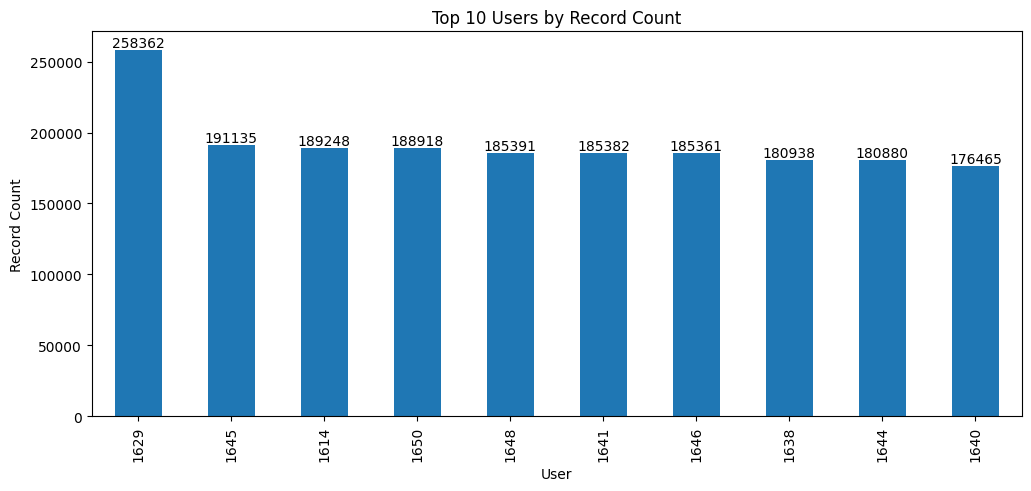

In [ ]:
user_counts = filtered_df['user'].value_counts()
print("Total users:", len(user_counts))

plt.figure(figsize=(12,5))
ax = user_counts.head(10).plot(kind='bar')
plt.title("Top 10 Users by Record Count")
plt.xlabel("User")
plt.ylabel("Record Count")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()

In [ ]:
print('Per-user class distribution of the top users\n')

top_users = user_counts.head(10).index.tolist()
per_user_class = filtered_df[filtered_df['user'].isin(top_users)].groupby(['user','final_activity_int']).size().unstack(fill_value=0)

print(per_user_class)

Per-user class distribution of the top users

final_activity_int      0      1      2      3      4       5
user                                                         
1614                22429  20848  20881  20847  20850   83393
1629                28698  28702  28700  28702  28698  114862
1638                20600  20600  20595  20599  20596   77948
1640                20596  20598  16132  20597  16134   82408
1641                20617  20600  20595  20595  20597   82378
1644                20596  20596  20594  20595  20592   77907
1645                20598  20597  24924  20598  20592   83826
1646                20601  20603  20596  20595  20593   82373
1648                20596  20601  20599  20595  20623   82377
1650                24131  20597  20596  20595  20596   82403


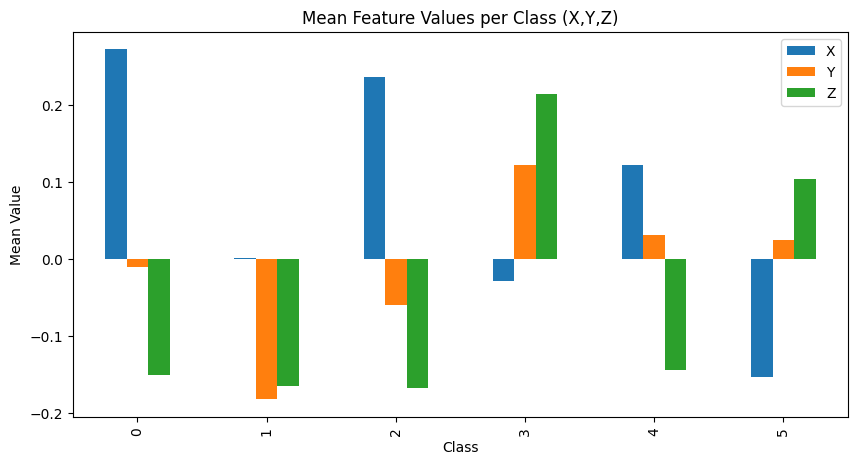

In [ ]:
# mean

feat_means = filtered_df.groupby('final_activity_int')[['X','Y','Z']].mean()
feat_means.plot(kind='bar', figsize=(10,5))
plt.title("Mean Feature Values per Class (X,Y,Z)")
plt.xlabel("Class")
plt.ylabel("Mean Value")
plt.show()

This plot shows that each activity has a distinct average sensor orientation.

Dynamic activities like walking and stairs have higher X/Z means, jogging shifts the orientation downward, sitting and standing show stable positive Z dominance, and eating sits between static and mild-movement patterns.

These differences confirm that the simple axis means carry significant class-discriminative informaiton.

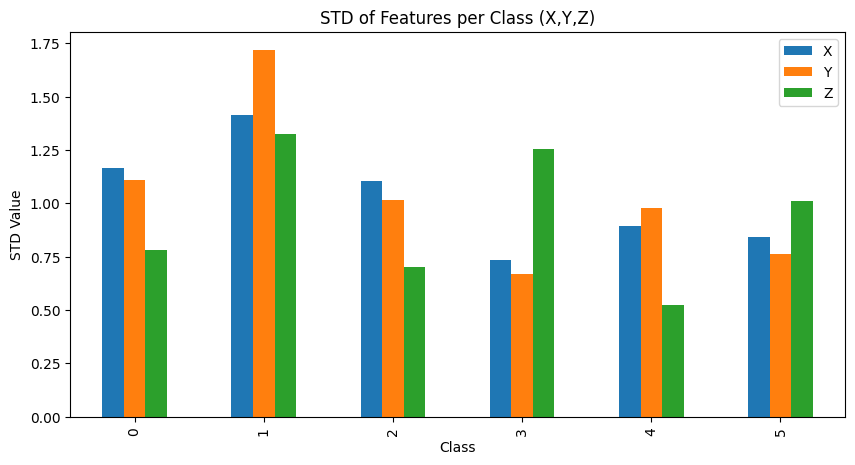

In [ ]:
# stds

feat_stds = filtered_df.groupby('final_activity_int')[['X','Y','Z']].std()
feat_stds.plot(kind='bar', figsize=(10,5))
plt.title("STD of Features per Class (X,Y,Z)")
plt.xlabel("Class")
plt.ylabel("STD Value")
plt.show()

The STD plot highlights movement intensity differences.

Jogging shows the highest variance across all axes, followed by walking and stairs, aligning with higher physical activity. Sitting and standing have very low variance, consistent with stationary postures. Eating exhibits moderate variance due to small, irregular movements. This validates that variance-based features clearly differentiate motion and non-motion activities.

---

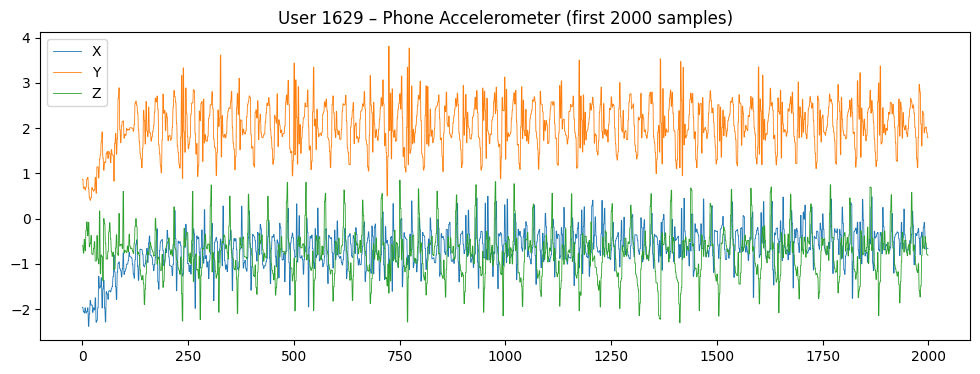

In [ ]:
sample_user = top_users[0]  # from earlier
df_u = filtered_df[(filtered_df['user']==sample_user) &
                   (filtered_df['device']=='phone') &
                   (filtered_df['sensor']=='accel')]

df_u = df_u.copy()
df_u['timestamp'] = df_u.groupby(['user','device','sensor']).cumcount()

plt.figure(figsize=(12,4))
plt.plot(df_u['timestamp'].head(2000), df_u['X'].head(2000), label="X", linewidth=0.6)
plt.plot(df_u['timestamp'].head(2000), df_u['Y'].head(2000), label="Y", linewidth=0.6)
plt.plot(df_u['timestamp'].head(2000), df_u['Z'].head(2000), label="Z", linewidth=0.6)
plt.legend()
plt.title(f"User {sample_user} – Phone Accelerometer (first 2000 samples)")
plt.show()

The user-level time-series shows smoothly sampled and consistent sensor signals with clear periodic movement in X and Z axes and stable Y-axis baseline. The synthetic timestamps produce a clean temporal progression without irregular jumps. This means that the preprocessing pipeline works correctly and preserves natural motion patterns.

### Multiclass Plots

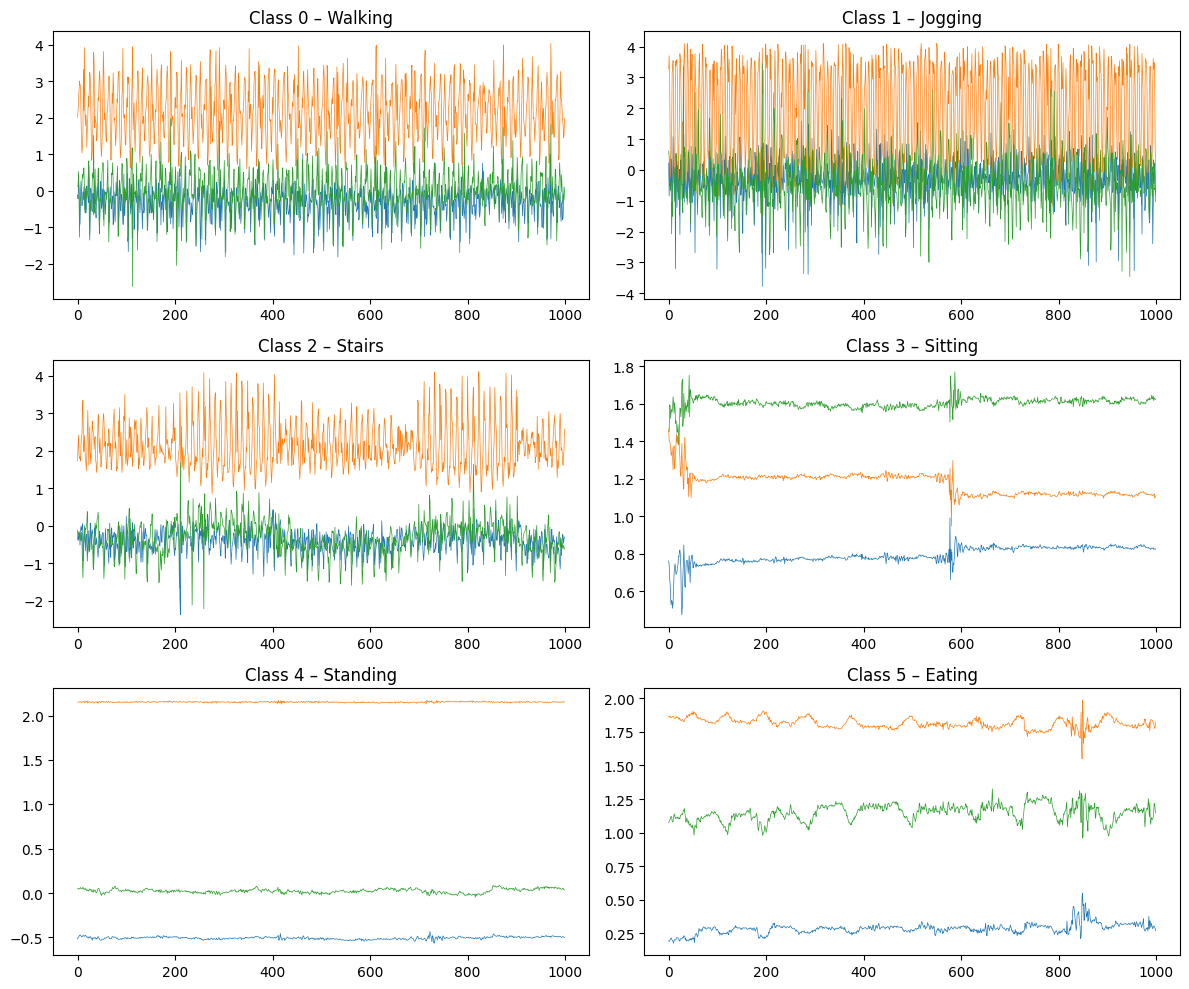

In [ ]:
# class name mapping
class_name_map = {
    0: "Walking",
    1: "Jogging",
    2: "Stairs",
    3: "Sitting",
    4: "Standing",
    5: "Eating"
}

classes = sorted(filtered_df['final_activity_int'].unique())

plt.figure(figsize=(12, 10))

for i, cls in enumerate(classes):
    df_c = filtered_df[
        (filtered_df['final_activity_int'] == cls) &
        (filtered_df['device'] == 'phone') &
        (filtered_df['sensor'] == 'accel')
    ].head(1000).copy()

    df_c['timestamp'] = df_c.groupby(['user','device','sensor']).cumcount()

    plt.subplot(3, 2, i + 1)
    plt.plot(df_c['timestamp'], df_c['X'], label='X', linewidth=0.5)
    plt.plot(df_c['timestamp'], df_c['Y'], label='Y', linewidth=0.5)
    plt.plot(df_c['timestamp'], df_c['Z'], label='Z', linewidth=0.5)

    # Title format: Class <number> – <name>
    plt.title(f"Class {cls} – {class_name_map[cls]}")
    plt.tight_layout()

plt.show()

* walking and stairs show rhythmic periodic oscillations;

* jogging is faster and higher-amplitude;

* sitting and standing are nearly flat;

* and eating shows low-intensity irregular fluctuations.


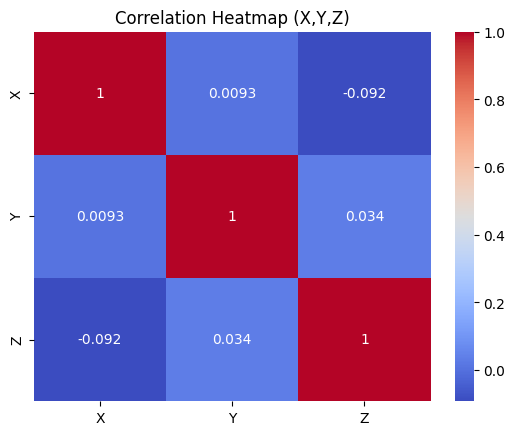

In [ ]:
corr = filtered_df[['X','Y','Z']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (X,Y,Z)")
plt.show()

## Model Training

In [ ]:
N_OUTPUTS = 6
N_TIMESTEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]

model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
                 input_shape=(N_TIMESTEPS, N_FEATURES)))
model.add(Dropout(0.5))
model.add(LSTM(100, return_sequences=True))
model.add(LSTM(100))
model.add(Dropout(0.5))
model.add(Dense(100, activation='relu'))
model.add(Dense(N_OUTPUTS, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', AUC(name='auc')])

print("\nRetrained Model Architecture (6 Outputs):")

EPOCHS = 20
BATCH_SIZE = 64

print(f'Training Model on {EPOCHS}: \n')

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)

print('Training Complete!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Retrained Model Architecture (6 Outputs):
Training Model on 20: 

Epoch 1/20
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6244 - auc: 0.9000 - loss: 0.9560 - val_accuracy: 0.7279 - val_auc: 0.9546 - val_loss: 0.6374
Epoch 2/20
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.7181 - auc: 0.9491 - loss: 0.6868 - val_accuracy: 0.7445 - val_auc: 0.9594 - val_loss: 0.6030
Epoch 3/20
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.7570 - auc: 0.9612 - loss: 0.5894 - val_accuracy: 0.7894 - val_auc: 0.9702 - val_loss: 0.5100
Epoch 4/20
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.7930 - auc: 0.9701 - loss: 0.5131 - val_accuracy: 0.8193 - val_auc: 0.9766 - val_loss: 0.4552
Epoch 5/20
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - accuracy: 0.8053 - auc: 0.9740 - loss: 0.4780 - val_accuracy: 0.8305 - val_auc: 0.9797 - val_loss: 0.4256
Epoch 6/20
1072/1072 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.8310 - auc: 0.9789 - loss: 0.4263 - val_acc

## Model Architecture Analysis

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 98, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 98, 100)        │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473,240 (1.81 MB)

 Trainable params: 157,746 (616.20 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 315,494 (1.20 MB)

```mermaid
graph TD
    A[Input Data (100, 3)] --> B{Conv1D Layer: Feature Extraction};
    B --> C{Dropout Layer: Regularization (0.5)};
    C --> D{LSTM Layer 1: Sequence Processing (return_sequences=True)};
    D --> E{LSTM Layer 2: Sequence Aggregation (returns single vector)};
    E --> F{Dropout Layer: Regularization (0.5)};
    F --> G{Dense Layer 1: Intermediate Processing (100 neurons, ReLU)};
    G --> H{Output Layer: Classification (6 neurons, Softmax)};
    H --> I[Activity Probabilities (0-5)];
```

**Explanation of Flow:**

1.  **Input Data (100, 3)**: Raw sensor data sequences (100 time steps, 3 features: X, Y, Z).
2.  **Conv1D Layer**: This layer scans the input sequences to automatically identify and extract local patterns and features.
3.  **Dropout Layer (1)**: Randomly drops connections during training to prevent overfitting.
4.  **LSTM Layer 1**: Processes the sequence of extracted features. Because `return_sequences=True`, it outputs a sequence of features for each time step, maintaining the temporal dimension for the next LSTM layer.
5.  **LSTM Layer 2**: Further processes the temporal information from the first LSTM layer. Since `return_sequences` is `False` by default, this layer condenses the entire input sequence into a single fixed-size vector, summarizing the learned temporal context.
6.  **Dropout Layer (2)**: Another regularization step applied to the summarized features from the LSTM.
7.  **Dense Layer 1**: A fully connected layer that takes the summarized and regularized features and transforms them into a higher-level representation.
8.  **Output Layer**: The final fully connected layer with 6 neurons (one for each activity class). The `softmax` activation function converts the outputs into probability distributions over the 6 classes.
9.  **Activity Probabilities (0-5)**: The final output, representing the model's confidence for each of the 6 activity classes.


--- Final Test Evaluation (6 Classes) ---
Test Loss: 0.2174
Test Accuracy: 0.9165
Test AUC: 0.9935
596/596 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

--- Classification Report ---
              precision    recall  f1-score   support

 Walking (A)       0.98      0.99      0.99      2202
 Jogging (B)       0.99      0.98      0.98      2147
  Stairs (C)       0.98      0.97      0.98      2046
 Sitting (D)       0.82      0.66      0.73      2117
Standing (E)       0.87      0.92      0.89      2158
      Eating       0.90      0.93      0.92      8382

    accuracy                           0.92     19052
   macro avg       0.92      0.91      0.91     19052
weighted avg       0.92      0.92      0.91     19052



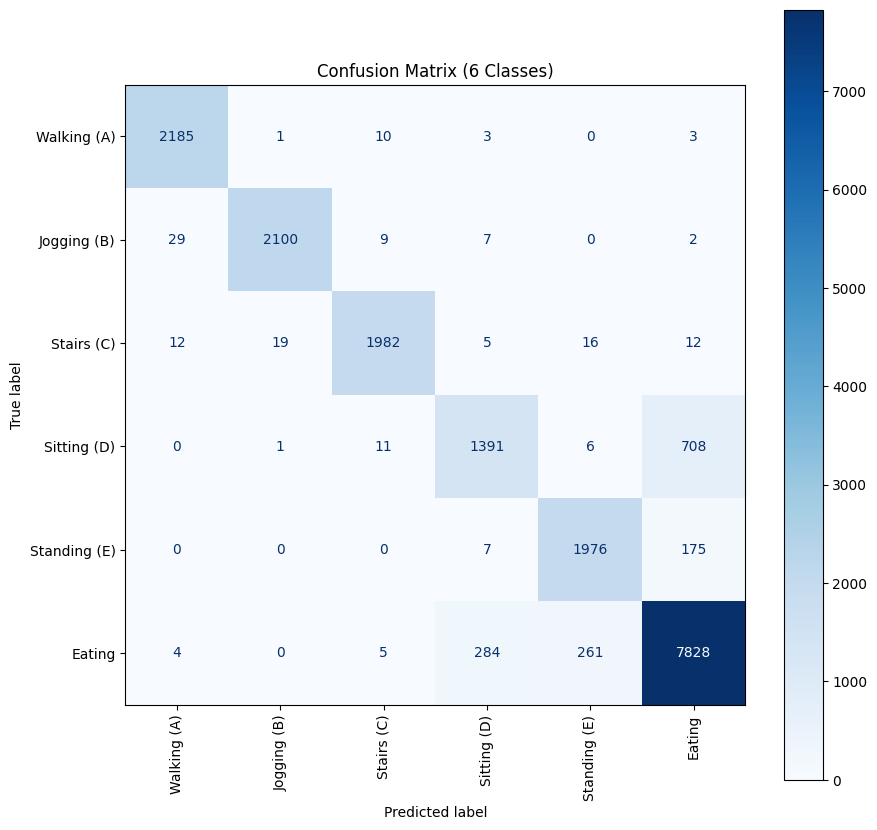

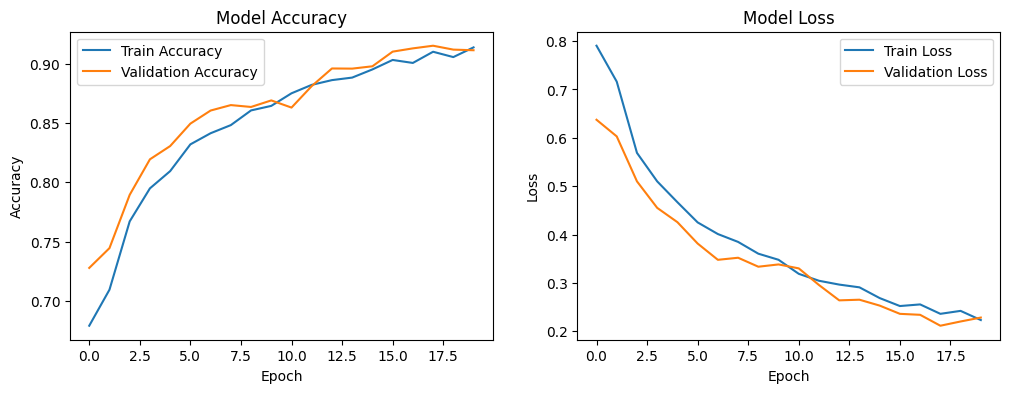

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

loss, accuracy, auc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)

print(f"\n--- Final Test Evaluation (6 Classes) ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

target_names = ['Walking (A)', 'Jogging (B)', 'Stairs (C)',
                'Sitting (D)', 'Standing (E)', 'Eating']

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix (6 Classes)')

plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

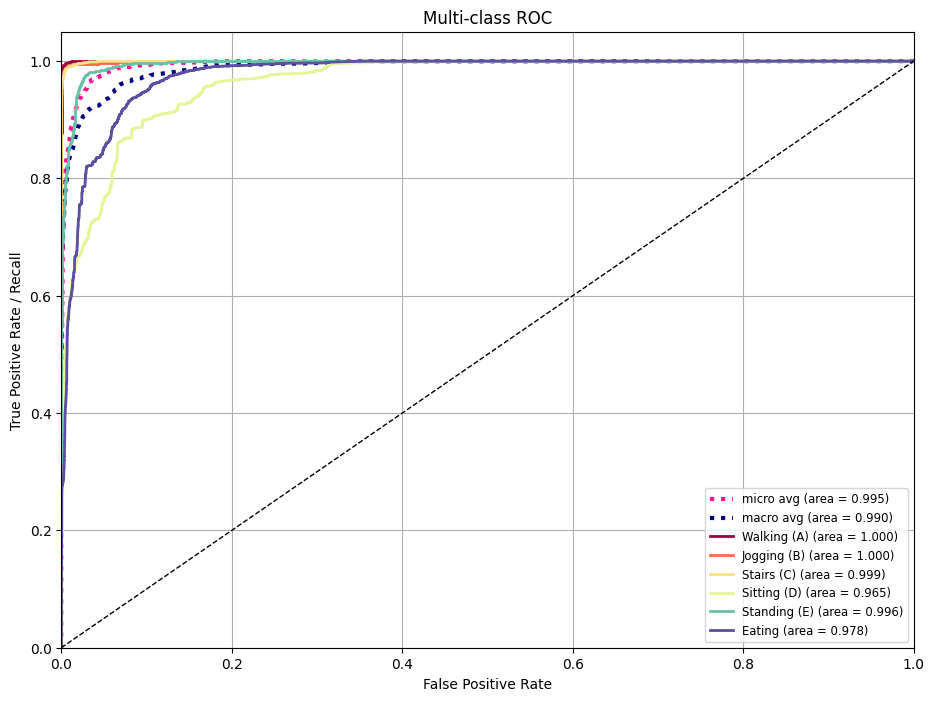

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from itertools import cycle
import sklearn.metrics as skm


try:
    y_pred_probs
except NameError:
    y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

target_names = ['Walking (A)', 'Jogging (B)', 'Stairs (C)',
                'Sitting (D)', 'Standing (E)', 'Eating']
N_OUTPUTS = len(target_names)

cm = skm.confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
fig_cm = px.imshow(cm_df, text_auto=True,
                   labels=dict(x="Predicted", y="True", color="Count"),
                   x=target_names, y=target_names, color_continuous_scale="Blues")
fig_cm.update_layout(title='Confusion Matrix (interactive)')

fpr = {}
tpr = {}
roc_auc = {}

for i in range(N_OUTPUTS):
    y_test_i = (y_test[:, i] == 1).astype(int)
    y_score_i = y_pred_probs[:, i]
    fpr[i], tpr[i], _ = skm.roc_curve(y_test_i, y_score_i)
    roc_auc[i] = skm.auc(fpr[i], tpr[i])   =

# micro-average
fpr["micro"], tpr["micro"], _ = skm.roc_curve(y_test.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = skm.auc(fpr["micro"], tpr["micro"])

# macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(N_OUTPUTS)]))
mean_tpr = np.zeros_like(all_fpr, dtype=float)
for i in range(N_OUTPUTS):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= N_OUTPUTS
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = skm.auc(fpr["macro"], tpr["macro"])

# plotting
plt.figure(figsize=(11,8))
plt.plot(fpr["micro"], tpr["micro"], label=f'micro avg (area = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=3)
plt.plot(fpr["macro"], tpr["macro"], label=f'macro avg (area = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=3)

colors = cycle(plt.get_cmap('Spectral')(np.linspace(0, 1, N_OUTPUTS)))
for i, color in zip(range(N_OUTPUTS), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{target_names[i]} (area = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate / Recall')
plt.title('Multi-class ROC')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True)
plt.show()
